<a href="https://colab.research.google.com/github/adityapri/Neural-Network---Multi-Class-Classification/blob/main/Multi_class_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

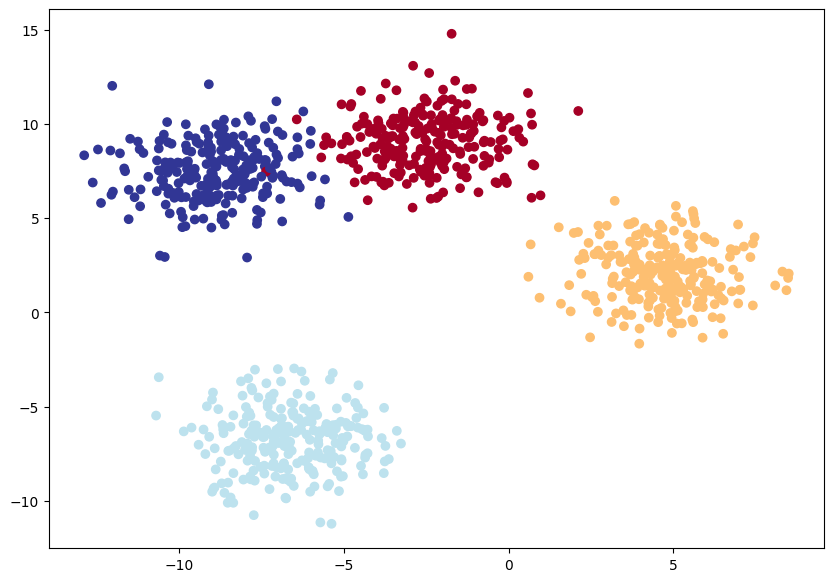

In [15]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Set the hyperparameters for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. Create multi-class data

X_blob, y_blob = make_blobs(n_samples=1000,
                            n_features=NUM_FEATURES,
                            centers=NUM_CLASSES,
                            cluster_std=1.5,
                            random_state=RANDOM_SEED)

# Turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.float)

# Split into train and test
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                        y_blob,
                                                                        test_size=0.2,
                                                                        random_state=RANDOM_SEED)

# Plot data (Visualize)
plt.figure(figsize=(10,7))
plt.scatter(X_blob[:,0],X_blob[:,1],c=y_blob, cmap=plt.cm.RdYlBu)

### Building a multi-class classification model in PyTorch

In [16]:
# Create device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [21]:
# Built a multi-class classification model
from torch import nn
class BlobModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units=8):
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        # nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        # nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_features),
    )

  def forward(self,x):
    return self.linear_layer_stack(x)

model = BlobModel(input_features=2,
                  output_features=4,
                  hidden_units=8).to(device)
model

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [22]:
model.state_dict()

OrderedDict([('linear_layer_stack.0.weight',
              tensor([[-0.6493,  0.4444],
                      [-0.1866, -0.3649],
                      [ 0.3327,  0.2903],
                      [-0.3013,  0.1869],
                      [-0.0515,  0.2940],
                      [ 0.6821,  0.1587],
                      [ 0.4019,  0.0141],
                      [ 0.7071,  0.6420]])),
             ('linear_layer_stack.0.bias',
              tensor([ 0.6914,  0.6924,  0.0080,  0.2870,  0.2463,  0.4749, -0.2185, -0.0836])),
             ('linear_layer_stack.1.weight',
              tensor([[-0.0449,  0.3002, -0.0323,  0.1657,  0.0752, -0.3220, -0.1857,  0.2236],
                      [-0.0764, -0.2925,  0.0405, -0.2528,  0.2782, -0.1341,  0.0496, -0.2141],
                      [-0.0752, -0.2343,  0.2600, -0.2551, -0.3241,  0.2574, -0.1185,  0.0408],
                      [ 0.0551,  0.1191,  0.2950,  0.3060, -0.1761, -0.1625,  0.0667,  0.1555],
                      [ 0.1597, -0.3494, -0.243

In [24]:
import re

def visualize_mlp_from_state_dict(model):
    state = model.state_dict()

    # ---- 1. Extract & sort weight matrices ----
    weight_items = []
    for k, v in state.items():
        if k.endswith(".weight"):
            match = re.search(r"\.(\d+)\.weight", k)
            idx = int(match.group(1)) if match else 0
            weight_items.append((idx, v.cpu().numpy(), k))

    weight_items.sort(key=lambda x: x[0])
    weights = [w for _, w, _ in weight_items]

    # ---- 2. Layer sizes ----
    layer_sizes = [weights[0].shape[1]]  # input size
    layer_sizes += [w.shape[0] for w in weights]

    num_layers = len(layer_sizes)

    # ---- 3. Neuron positions ----
    x_positions = np.linspace(0, num_layers - 1, num_layers)
    y_positions = [
        np.linspace(0, 1, size) for size in layer_sizes
    ]

    fig, ax = plt.subplots(figsize=(3 * num_layers, 8))

    # ---- 4. Plot neurons ----
    for x, ys in zip(x_positions, y_positions):
        ax.scatter([x] * len(ys), ys, s=350, zorder=3)

    # ---- 5. Plot connections + weights ----
    for layer_idx, W in enumerate(weights):
        x0, x1 = x_positions[layer_idx], x_positions[layer_idx + 1]
        y0, y1 = y_positions[layer_idx], y_positions[layer_idx + 1]

        for i in range(W.shape[0]):
            for j in range(W.shape[1]):
                w = W[i, j]

                ax.plot([x0, x1],
                        [y0[j], y1[i]],
                        color='blue' if w > 0 else 'red',
                        alpha=min(1.0, abs(w)))

                ax.text((x0 + x1) / 2,
                        (y0[j] + y1[i]) / 2,
                        f"{w:.2f}",
                        fontsize=7,
                        ha='center',
                        va='center')

    # ---- 6. Labels ----
    ax.set_xticks(x_positions)
    ax.set_xticklabels([f"Layer {i}" for i in range(num_layers)])
    ax.set_title("General MLP Visualization from model.state_dict()")
    ax.axis("off")

    plt.show()


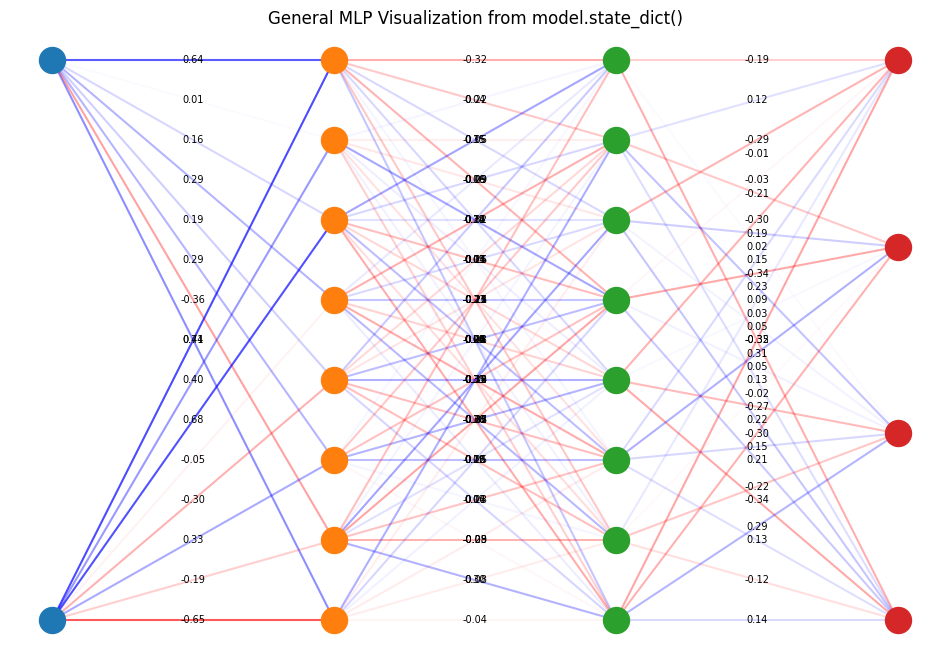

In [25]:
visualize_mlp_from_state_dict(model)

In [ ]:
# Create a loss function and an optimizer
